In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.regularizers import l2
import tensorflow as tf

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jainilcoder/netflix-stock-price-prediction/NFLX.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [4]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').drop(columns=['Adj Close']).set_index('Date')
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,16906900


In [6]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    # --- Returns ---
    d['Return'] = d['Close'].pct_change()
    d['LogReturn'] = np.log(d['Close'] / d['Close'].shift(1))

    # --- Moving averages / trend ---
    d['MA7']  = d['Close'].rolling(window=7).mean()
    d['MA21'] = d['Close'].rolling(window=21).mean()
    d['MA50'] = d['Close'].rolling(window=50).mean()
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()

    # --- Volatility ---
    d['Volatility7']  = d['Return'].rolling(window=7).std()
    d['Volatility21'] = d['Return'].rolling(window=21).std()

    # --- RSI (14) ---
    delta = d['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    d['RSI14'] = 100 - (100 / (1 + rs))

    # --- MACD ---
    ema12 = d['Close'].ewm(span=12, adjust=False).mean()
    ema26 = d['Close'].ewm(span=26, adjust=False).mean()
    d['MACD'] = ema12 - ema26
    d['MACD_signal'] = d['MACD'].ewm(span=9, adjust=False).mean()

    # --- Bollinger Band width ---
    bb_mid = d['Close'].rolling(window=20).mean()
    bb_std = d['Close'].rolling(window=20).std()
    d['BB_width'] = ((bb_mid + 2 * bb_std) - (bb_mid - 2 * bb_std)) / bb_mid

    # --- Lag features ---
    for lag in [1, 2, 3]:
        d[f'Close_lag_{lag}'] = d['Close'].shift(lag)

    # --- Spreads ---
    d['HL_spread'] = d['High'] - d['Low']
    d['OC_spread'] = d['Close'] - d['Open']

    # --- Volume ---
    d['Volume_change'] = d['Volume'].pct_change()

    # --- Calendar (cyclical day-of-week) ---
    dow = d.index.dayofweek
    d['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    d['dow_cos'] = np.cos(2 * np.pi * dow / 7)

    return d

df_feat = add_features(df)
df_feat = df_feat.dropna().reset_index()  # drop rows with NaN from rolling/lag windows
print(df_feat.shape)
df_feat.head()

(960, 26)


,Date,Open,High,Low,Close,Volume,Return,LogReturn,MA7,MA21,...,MACD_signal,BB_width,Close_lag_1,Close_lag_2,Close_lag_3,HL_spread,OC_spread,Volume_change,dow_sin,dow_cos
0,2018-04-17,329.660004,338.619995,323.769989,336.059998,33866500,0.091884,0.087904,308.058572,302.351908,...,1.409260,0.188344,307.779999,311.649994,309.250000,14.850006,6.399994,0.667652,0.781831,0.623490
1,2018-04-18,336.299988,338.820007,331.100006,334.519989,11221100,-0.004583,-0.004593,314.428571,303.353812,...,2.366048,0.206686,336.059998,307.779999,311.649994,7.720001,-1.779999,-0.668667,0.974928,-0.222521
2,2018-04-19,332.880005,335.309998,326.769989,332.700012,8438800,-0.005441,-0.005455,319.375715,304.077622,...,3.383515,0.221089,334.519989,336.059998,307.779999,8.540009,-0.179993,-0.247953,0.433884,-0.900969
3,2018-04-20,332.220001,336.510010,326.000000,327.769989,9158700,-0.014818,-0.014929,322.818569,304.615240,...,4.299310,0.231547,332.700012,334.519989,336.059998,10.510010,-4.450012,0.085308,-0.433884,-0.900969
4,2018-04-23,329.149994,331.220001,317.079987,318.690002,8968000,-0.027702,-0.028093,324.167140,305.186192,...,4.948706,0.234223,327.769989,332.700012,334.519989,14.140014,-10.459992,-0.020822,0.000000,1.000000


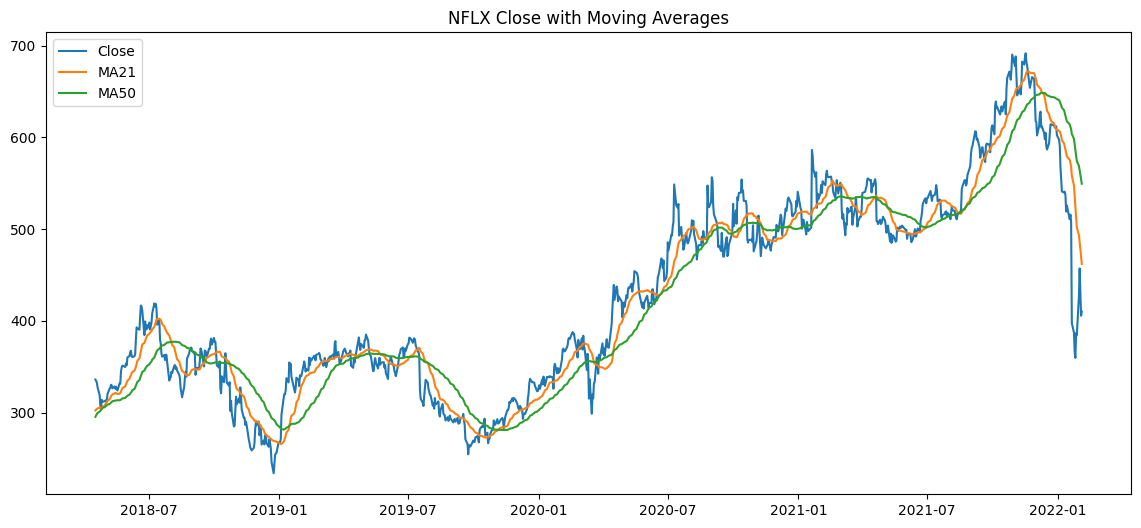

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df_feat['Date'], df_feat['Close'], label='Close')
plt.plot(df_feat['Date'], df_feat['MA21'], label='MA21')
plt.plot(df_feat['Date'], df_feat['MA50'], label='MA50')
plt.legend()
plt.title('NFLX Close with Moving Averages')
plt.show()

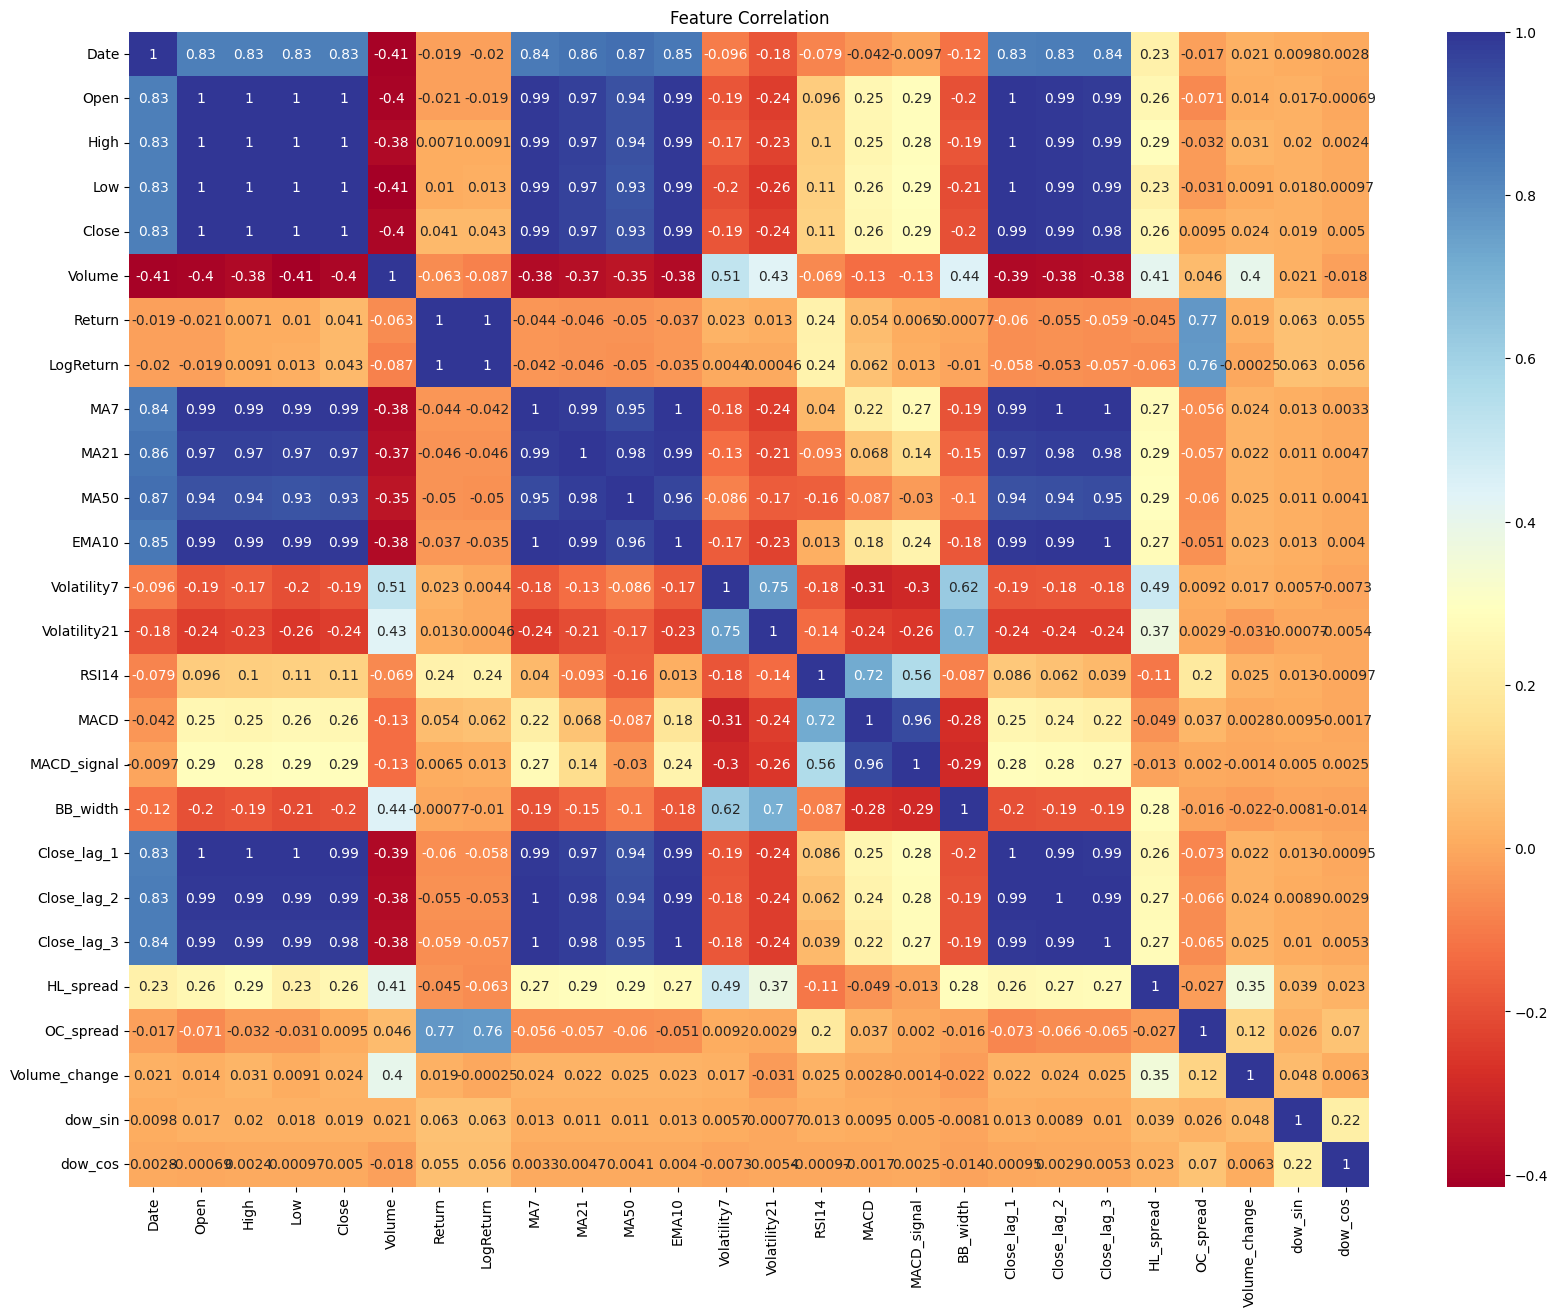

In [8]:
plt.figure(figsize=(20,15))
sns.heatmap(df_feat.corr(), annot=True, cmap="RdYlBu")
plt.title("Feature Correlation")
plt.show()

In [9]:
feature_cols = [c for c in df_feat.columns if c not in ['Date']]
target_col = 'Close'

split_idx = int(len(df_feat) * 0.85)
train_df = df_feat.iloc[:split_idx]
test_df  = df_feat.iloc[split_idx:]

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Train dates: {train_df['Date'].min()} -> {train_df['Date'].max()}")
print(f"Test dates:  {test_df['Date'].min()} -> {test_df['Date'].max()}")

Train: (816, 26), Test: (144, 26)
Train dates: 2018-04-17 00:00:00 -> 2021-07-13 00:00:00
Test dates:  2021-07-14 00:00:00 -> 2022-02-04 00:00:00


In [10]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
test_scaled  = scaler.transform(test_df[feature_cols])

target_idx = feature_cols.index(target_col)
print("Target column index in feature_cols:", target_idx)

Target column index in feature_cols: 3


In [11]:
def create_windowed_sequences(data: np.ndarray, target_idx: int, window: int = 60):
    """
    Per-window Min-Max normalization.
    Each window is scaled using its OWN min/max, not a global scaler.
    This fixes extrapolation when price levels drift far from the train range.
    """
    X, y = [], []
    target_min, target_max = [], []

    for i in range(window, len(data)):
        window_data = data[i - window:i]          # last 60 days, raw values
        w_min = window_data.min(axis=0)
        w_max = window_data.max(axis=0)
        denom = np.where(w_max - w_min == 0, 1, w_max - w_min)  # avoid /0 on flat columns

        X_scaled = (window_data - w_min) / denom
        target_raw = data[i, target_idx]
        y_scaled = (target_raw - w_min[target_idx]) / denom[target_idx]

        X.append(X_scaled)
        y.append(y_scaled)
        target_min.append(w_min[target_idx])
        target_max.append(w_max[target_idx])

    return (np.array(X), np.array(y),
            np.array(target_min), np.array(target_max))

WINDOW = 60

train_raw = train_df[feature_cols].values
test_raw  = test_df[feature_cols].values

X_train, y_train, train_tmin, train_tmax = create_windowed_sequences(train_raw, target_idx, WINDOW)
X_test,  y_test,  test_tmin,  test_tmax  = create_windowed_sequences(test_raw,  target_idx, WINDOW)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

X_train: (756, 60, 25) y_train: (756,)
X_test:  (84, 60, 25) y_test:  (84,)


In [12]:
model_LSTM = Sequential([

    LSTM(
        512,
        return_sequences=True,
        input_shape=(60,25),

        kernel_initializer="glorot_uniform",
        kernel_regularizer=l2(0.001),
        recurrent_regularizer=l2(0.001)),

    BatchNormalization(),
    Dropout(0.3),

    LSTM(
        256,
        return_sequences=False,

        kernel_initializer="glorot_uniform",
        kernel_regularizer=l2(0.001),
        recurrent_regularizer=l2(0.001)),

    BatchNormalization(),
    Dropout(0.3),

    Dense(
        128,
        activation="relu",

        kernel_initializer="he_normal",
        kernel_regularizer=l2(0.001)
    ),

    Dense(1)
])

model_LSTM.summary()

I0000 00:00:1785375911.660494      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 512)        │     1,101,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,925,377 (7.34 MB)

 Trainable params: 1,923,841 (7.34 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [13]:
model_LSTM.compile(
    optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.001),
    loss="mse",
    metrics=["mae"])

# Callbacks
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),


    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),


    ModelCheckpoint(
        "best_LSTM.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


In [14]:
history_LSTM = model_LSTM.fit(
    X_train,
    y_train,
    
    validation_split=0.2,
    epochs=100,
    
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 3.5044 - mae: 0.9934 - val_loss: 1.8935 - val_mae: 0.2817 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4932 - mae: 0.6643 - val_loss: 2.0137 - val_mae: 0.4080 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.2893 - mae: 0.5724 - val_loss: 1.9520 - val_mae: 0.3589 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.2120 - mae: 0.5359 - val_loss: 1.9032 - val_mae: 0.3494 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 2.0486 - mae: 0.4498 - val_loss: 1.8203 - val_mae: 0.2616 - learning_rate: 5.0000e-04
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 2.0286 - mae: 0.4382 - val_loss: 1.7832 - val_mae: 0.2395 - learning_rate: 5.0000e-04
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.9677 - mae: 0.4114 - val_loss: 1.7744 - val_mae: 0.2435 - learning_rate: 5.000

In [15]:
model_GRU = Sequential([

    GRU(
        128,
        return_sequences=True,
        input_shape=(60,25),

        kernel_initializer="glorot_uniform",
        kernel_regularizer=l2(0.001),
        recurrent_regularizer=l2(0.001)),

    BatchNormalization(),
    Dropout(0.3),

    GRU(
        64,
        return_sequences=False,

        kernel_initializer="glorot_uniform",
        kernel_regularizer=l2(0.001),
        recurrent_regularizer=l2(0.001)),

    BatchNormalization(),
    Dropout(0.3),

    Dense(
        64,
        activation="relu",

        kernel_initializer="he_normal",
        kernel_regularizer=l2(0.001)
    ),

    Dense(1)
])

model_GRU.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │        59,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,761 (397.50 KB)

 Trainable params: 101,377 (396.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
model_GRU.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True),
    
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6),

    ModelCheckpoint(
        "best_GRU.keras",
        monitor="val_loss",
        save_best_only=True)]


history_GRU = model_GRU.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 1.5311 - mae: 0.7911 - val_loss: 0.5690 - val_mae: 0.1821 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1783 - mae: 0.6374 - val_loss: 0.6045 - val_mae: 0.2548 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9189 - mae: 0.5125 - val_loss: 0.5725 - val_mae: 0.2191 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7792 - mae: 0.4260 - val_loss: 0.5422 - val_mae: 0.1822 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7867 - mae: 0.4356 - val_loss: 0.5328 - val_mae: 0.1845 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7021 - mae: 0.3783 - val_loss: 0.5113 - val_mae: 0.1647 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6403 - mae: 0.3396 - val_loss: 0.4975 - val_mae: 0.1583 - learning_rate: 0.0010
Epoch 

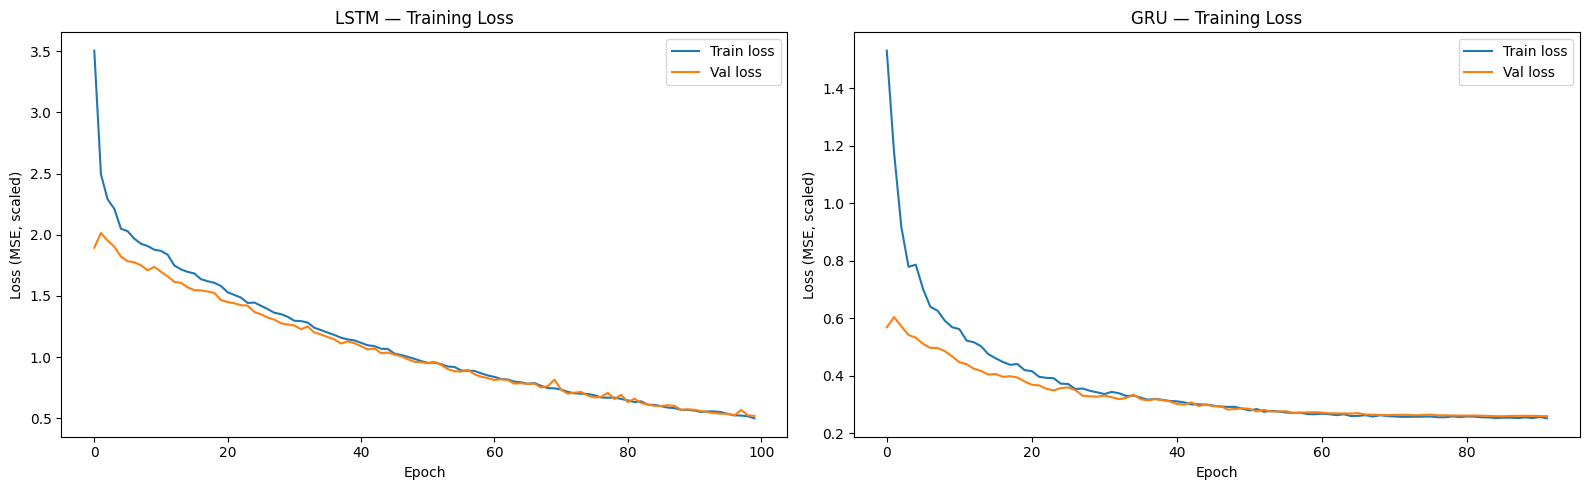

In [17]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- LSTM subplot ---
    axes[0].plot(history_LSTM.history['loss'],     label='Train loss')
    axes[0].plot(history_LSTM.history['val_loss'], label='Val loss')
    axes[0].set_title("LSTM — Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (MSE, scaled)")
    axes[0].legend()

    # --- GRU subplot ---
    axes[1].plot(history_GRU.history['loss'],     label='Train loss')
    axes[1].plot(history_GRU.history['val_loss'], label='Val loss')
    axes[1].set_title("GRU — Training Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss (MSE, scaled)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

except NameError:
    print("Run this after saving history_LSTM / history_GRU from model.fit(...)")

In [18]:
def inverse_transform_target(scaled_values, scaler, feature_cols, target_idx):
    """Inverse-transform a 1D array of scaled target values back to original scale."""
    dummy = np.zeros((len(scaled_values), len(feature_cols)))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

# --- Predictions (scaled) ---
pred_lstm_scaled = model_LSTM.predict(X_test).ravel()
pred_gru_scaled  = model_GRU.predict(X_test).ravel()

# --- Back to real price scale ---
y_test_real    = inverse_transform_target(y_test,           scaler, feature_cols, target_idx)
pred_lstm_real = inverse_transform_target(pred_lstm_scaled,  scaler, feature_cols, target_idx)
pred_gru_real  = inverse_transform_target(pred_gru_scaled,   scaler, feature_cols, target_idx)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [19]:
# --- Metrics ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R2": r2}

results = pd.DataFrame([
    evaluate(y_test_real, pred_lstm_real, "LSTM"),
    evaluate(y_test_real, pred_gru_real,  "GRU"),
]).set_index("Model")

results

,RMSE,MAE,MAPE (%),R2
Model,,,,
LSTM,38.645476,27.965894,17.760905,0.931864
GRU,52.253016,36.419027,25.147019,0.875433


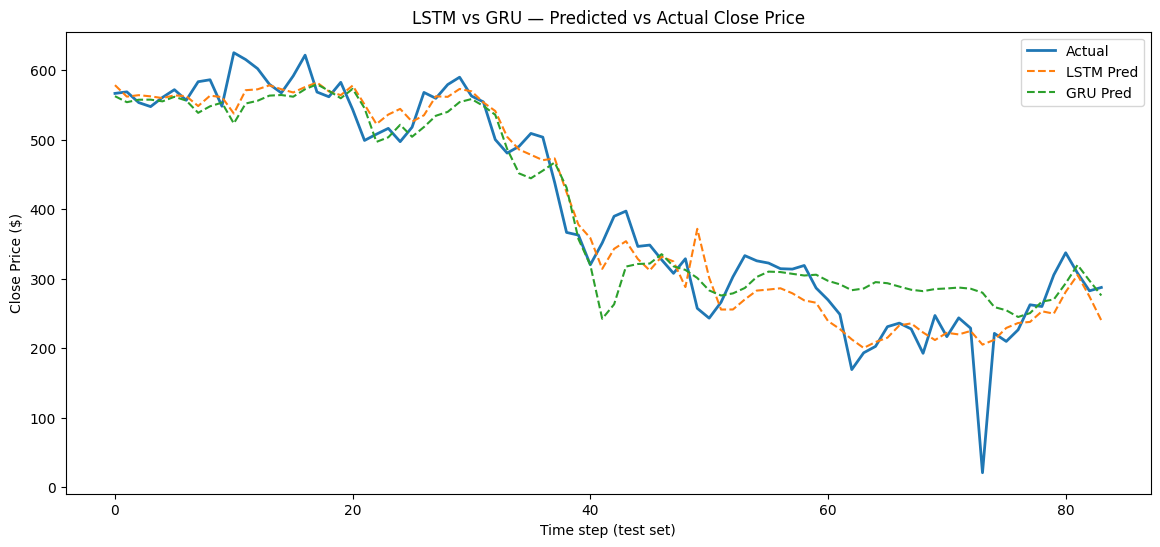

In [20]:
# --- Actual vs Predicted plot ---
plt.figure(figsize=(14, 6))
plt.plot(y_test_real,    label="Actual",    linewidth=2)
plt.plot(pred_lstm_real, label="LSTM Pred", linestyle="--")
plt.plot(pred_gru_real,  label="GRU Pred",  linestyle="--")
plt.title("LSTM vs GRU — Predicted vs Actual Close Price")
plt.xlabel("Time step (test set)")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()

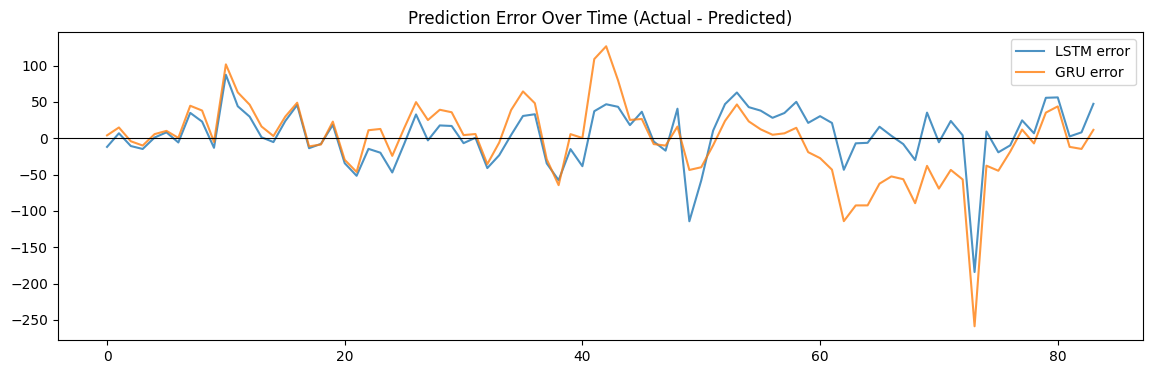

In [21]:
# --- Error over time ---
err_lstm = y_test_real - pred_lstm_real
err_gru  = y_test_real - pred_gru_real

plt.figure(figsize=(14, 4))
plt.plot(err_lstm, label="LSTM error", alpha=0.8)
plt.plot(err_gru,  label="GRU error",  alpha=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Prediction Error Over Time (Actual - Predicted)")
plt.legend()
plt.show()

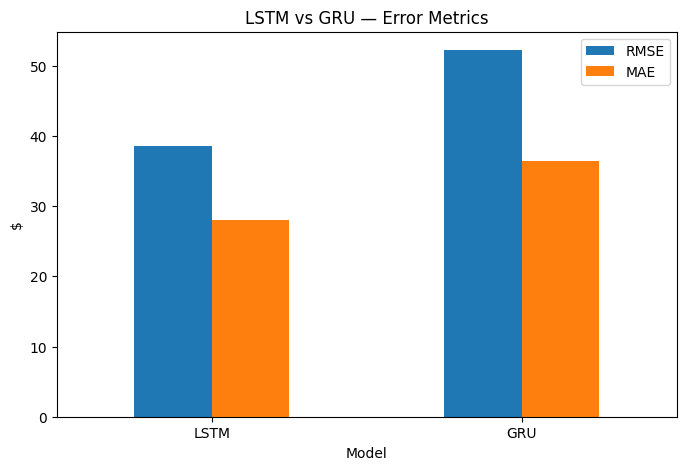

In [22]:
# --- Bar chart comparison ---
results[["RMSE", "MAE"]].plot(kind="bar", figsize=(8, 5), title="LSTM vs GRU — Error Metrics")
plt.ylabel("$")
plt.xticks(rotation=0)
plt.show()